# Parsing DCP-Bench-Open

This notebook shows how to start working with the dataset to gather statistics or anything related.

In [5]:
import json

# read json file (make sure this is available in the same directory)
with open("dcp-bench-open.jsonl", "r") as f:
    dataset = [json.loads(line) for line in f]

In [6]:
print(dataset[0].keys())

dict_keys(['id', 'metadata', 'description', 'example_instance', 'instances', 'model', 'example_solution', 'decision_variables'])


In [7]:
num_problems_multiple_instances = sum(1 for problem in dataset if len(problem["instances"]) > 1)
print(f"Number of problems with more than one instance: {num_problems_multiple_instances}")

Number of problems with more than one instance: 23


In [8]:
problems_with_multiple_instances = [problem for problem in dataset if len(problem["instances"]) > 1]
average_instances = sum(len(problem["instances"]) for problem in problems_with_multiple_instances) / len(problems_with_multiple_instances)
print(f"Average number of instances per problem (for problems with more than one instance): {average_instances:.2f}")

Average number of instances per problem (for problems with more than one instance): 9.35


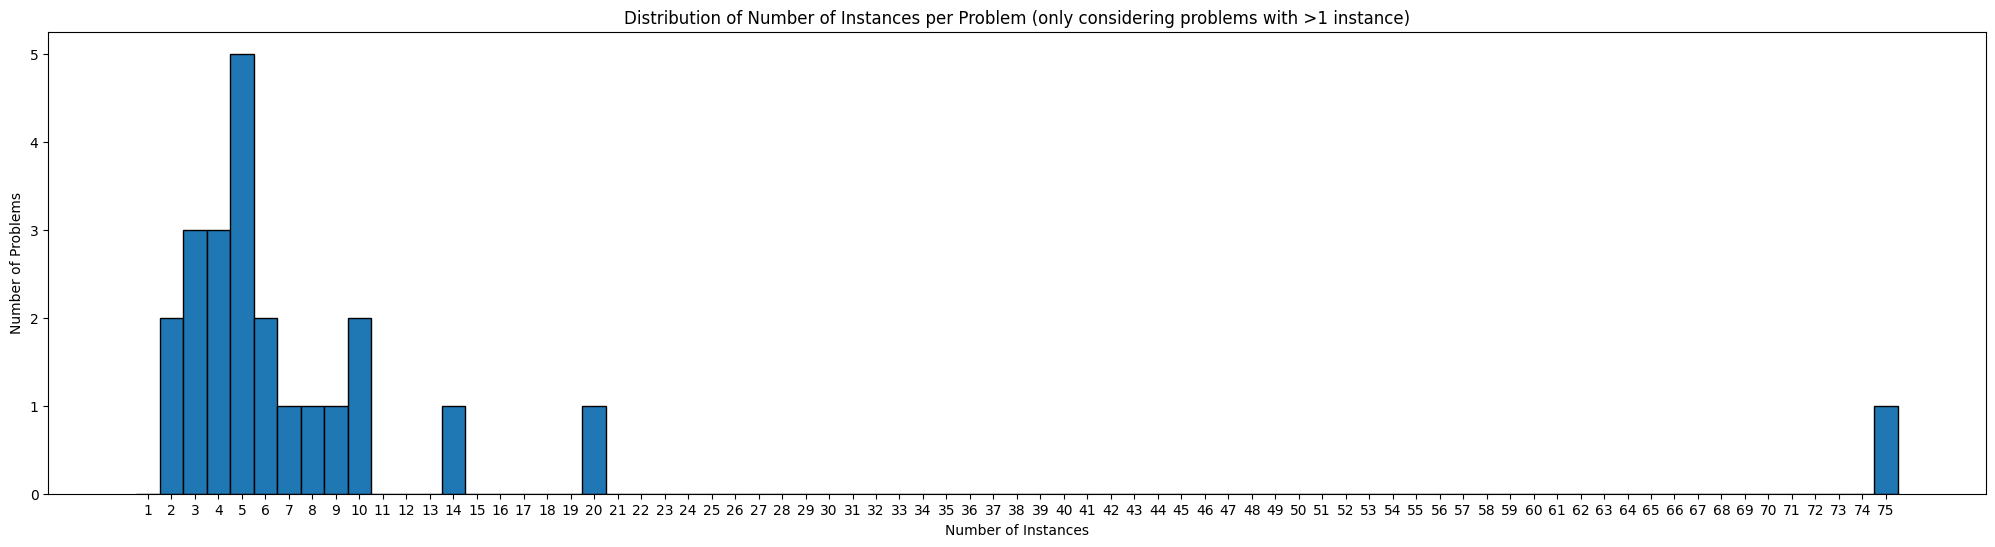

In [9]:
import matplotlib.pyplot as plt

instance_counts = [len(problem["instances"]) for problem in problems_with_multiple_instances]
plt.hist(instance_counts, bins=range(1, max(instance_counts) + 2), align='left', edgecolor='black')
plt.xlabel('Number of Instances')
plt.ylabel('Number of Problems')
plt.title('Distribution of Number of Instances per Problem (only considering problems with >1 instance)')
plt.xticks(range(1, max(instance_counts) + 1))
plt.gcf().set_size_inches(25, 6)

plt.show()